In [1]:
# Library Imports
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Gasoline Tax dataset
dataset_url = 'https://data.ontario.ca/dataset/48de187d-84bb-4634-9f66-f998f3dce4d2/resource/65f060c7-f6fb-4078-b0f0-03877ba99548/download/gasoline-tax-rates.csv'

In [3]:
df = pd.read_csv(dataset_url)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 8 columns):
 #   Column                                                       Non-Null Count  Dtype  
---  ------                                                       --------------  -----  
 0   Effective Date (Date d'entrée en vigeur)                     28 non-null     object 
 1   Regular Leaded (Régulier au plomb) ¢/litre                   28 non-null     float64
 2   Regular Unleaded (Régulier sans plomb) ¢/litre               28 non-null     float64
 3   Premium Leaded (Supérieur au plomb) ¢/litre                  28 non-null     float64
 4   Premium Unleaded (Supérieur sans plomb) ¢/litre              28 non-null     float64
 5   Aviation Fuel (Carburant aviation) ¢/litre                   28 non-null     float64
 6   Aviation Fuel North ON (Carburant aviation Nord ON) ¢/litre  3 non-null      float64
 7   Propane ¢/litre                                              11 non-null     float6

In [ ]:
# Convert date column to datetime
df['Effective Date'] = pd.to_datetime(df["Effective Date (Date d'entrée en vigeur)"])
columns_to_drop = ["Effective Date (Date d'entrée en vigeur)", "Aviation Fuel (Carburant aviation) ¢/litre", "Aviation Fuel North ON (Carburant aviation Nord ON) ¢/litre", "Propane ¢/litre"]
df.drop(columns_to_drop, axis=1, inplace=True)

# Sort by date
df = df.sort_values('Effective Date')

# Set date as index (helps plotting)
df.set_index('Effective Date', inplace=True)

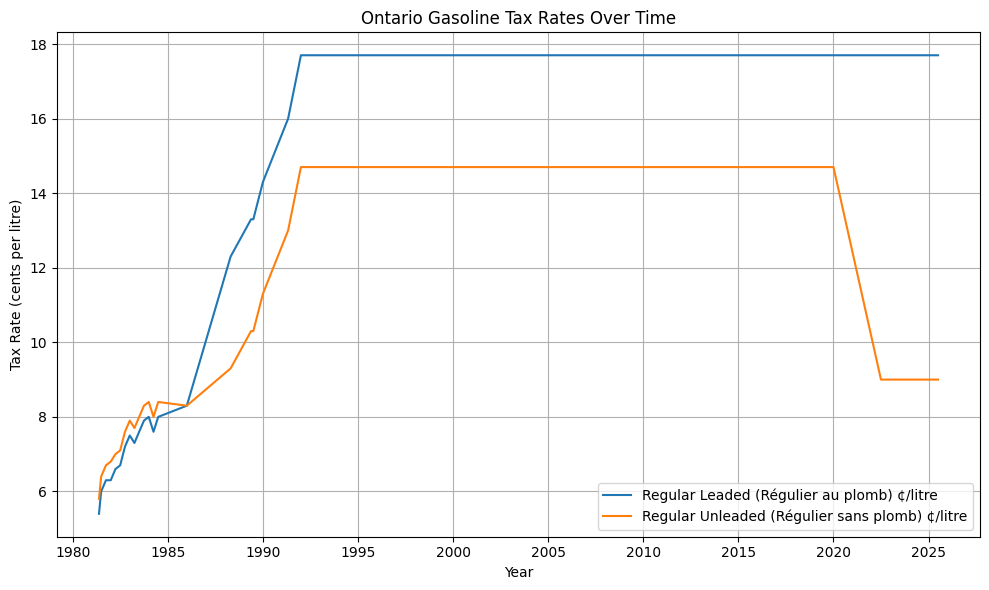

In [18]:

fig, ax = plt.subplots(figsize=(10, 6))

# Plot each fuel type as a separate line

columns_to_plot = ["Regular Leaded (Régulier au plomb) ¢/litre", "Regular Unleaded (Régulier sans plomb) ¢/litre"]

for column in columns_to_plot:
    ax.plot(df.index, df[column], label=column)

# Labels and formatting
plt.title('Ontario Gasoline Tax Rates Over Time')
plt.xlabel('Year')
plt.ylabel('Tax Rate (cents per litre)')
plt.legend(loc='best')
plt.grid()

plt.tight_layout()
plt.show()

In [19]:
df[columns_to_plot]

,Regular Leaded (Régulier au plomb) ¢/litre,Regular Unleaded (Régulier sans plomb) ¢/litre
Effective Date,,
1981-05-20,5.4,5.8
1981-07-01,6.0,6.4
1981-10-01,6.3,6.7
1982-01-01,6.3,6.8
1982-04-01,6.6,7.0
1982-07-01,6.7,7.1
1982-10-01,7.2,7.6
1983-01-01,7.5,7.9
1983-04-01,7.3,7.7
